Saving WhatsApp Image 2025-12-18 at 14.59.36.jpeg to WhatsApp Image 2025-12-18 at 14.59.36.jpeg
Uploaded File: WhatsApp Image 2025-12-18 at 14.59.36.jpeg

Image Information:
  Dimensions : 590 x 1280
  Channels   : 3
  File size  : 124.06 KB
  Data type  : uint8


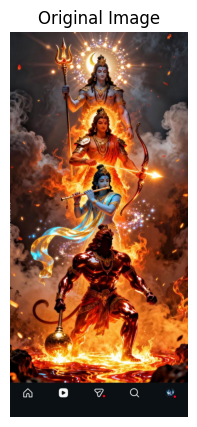

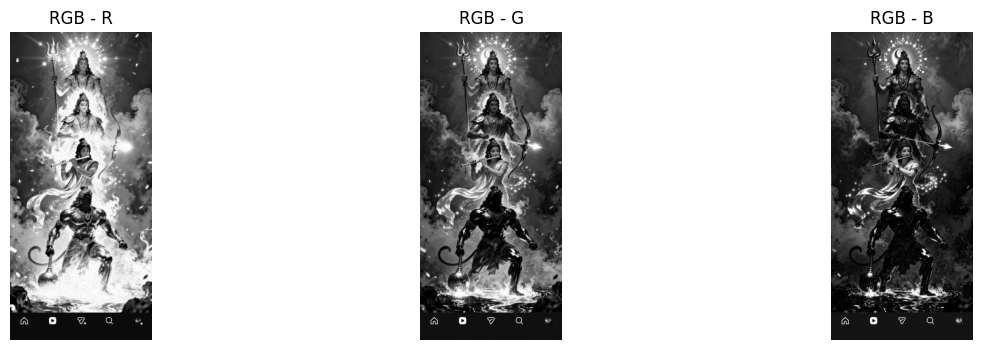

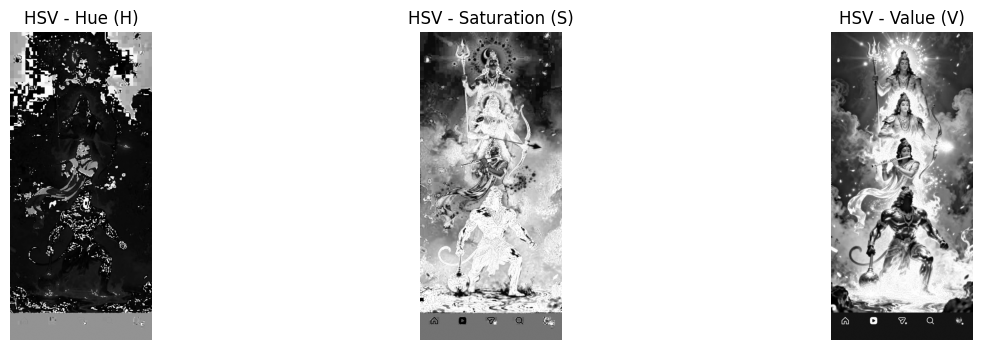

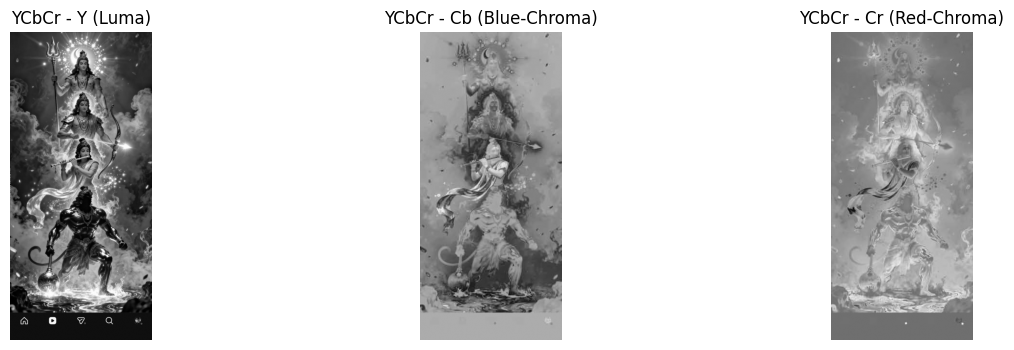

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# ---------------------------------------------
# 1. Ask user to upload an image
# ---------------------------------------------
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print("Uploaded File:", filename)

# ---------------------------------------------
# 2. Read the uploaded image
# ---------------------------------------------
img_bgr = cv2.imread(filename)

if img_bgr is None:
    raise ValueError("Error: Image could not be loaded")

h, w = img_bgr.shape[:2]
channels = img_bgr.shape[2]
size_kb = os.path.getsize(filename) / 1024

print("\nImage Information:")
print(f"  Dimensions : {w} x {h}")
print(f"  Channels   : {channels}")
print(f"  File size  : {size_kb:.2f} KB")
print(f"  Data type  : {img_bgr.dtype}")

# Convert BGR → RGB (for display)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Show original image
plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# ---------------------------------------------
# 3. Convert RGB → HSV and YCbCr
# ---------------------------------------------
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

# Split channels
R, G, B = cv2.split(img_rgb)
H, S, V = cv2.split(img_hsv)
Y, Cr, Cb = cv2.split(img_ycrcb)

# ---------------------------------------------
# Helper function to show each channel
# ---------------------------------------------
def show_channels(title, channels, names):
    plt.figure(figsize=(15, 4))
    for i, (ch, name) in enumerate(zip(channels, names), 1):
        plt.subplot(1, len(channels), i)
        plt.imshow(ch, cmap="gray")
        plt.title(f"{title} - {name}")
        plt.axis("off")
    plt.show()

# ---------------------------------------------
# 4. Display all channels
# ---------------------------------------------
show_channels("RGB", [R, G, B], ["R", "G", "B"])
show_channels("HSV", [H, S, V], ["Hue (H)", "Saturation (S)", "Value (V)"])
show_channels("YCbCr", [Y, Cb, Cr], ["Y (Luma)", "Cb (Blue-Chroma)", "Cr (Red-Chroma)"])